# Notebook 2 — SOLUTION

## Short version

Both datasets were generated with **control and test identical** -- there is no
condition difference anywhere. The apparent reduction comes from a single error:
each neuron's **preferred direction is chosen from the control data**, and then
the response is read out *at that same direction*. Selecting on the data you then
measure (circular analysis / double dipping) biases the selected value upward --
the **winner's curse** (Kriegeskorte et al., 2009; Vul et al., 2009).

We show this in two acts:

- **Act 1 — real tuning, fake difference.** The neurons in `tuned.npz` are
  genuinely orientation tuned. The tuning is real and survives cross-validation,
  but the control-vs-test *difference* is entirely manufactured by selection.
- **Act 2 — no tuning, fake everything.** In `untuned.npz` there is no tuning at
  all. The same pipeline invents the whole tuning curve *and* the difference from
  pure noise.

The single fix for both: **select the preferred direction on independent data.**


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

# --- Plotting style ---
plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

CONTROL, TEST = 0, 1
COND_COLOR = {'control': 'k', 'test': '0.6'}
COND_LABEL = {'control': 'Control', 'test': 'Test'}
rng = np.random.default_rng(0)

def load(fname):
    d = np.load(fname, allow_pickle=True)
    return (d['counts'], float(d['duration']), d['orientations'],
            [str(x) for x in d['condition_names']])

def preferred_ori(rate_by_ori):
    # argmax over orientation, breaking ties AT RANDOM. Counts are small
    # integers so exact ties are common; np.argmax's first-index rule would
    # bias the "preferred" orientation toward the first-listed direction.
    return (rate_by_ori + rng.uniform(0, 1e-9, rate_by_ori.shape)).argmax(1)

def roll_to_center(rate_by_ori, pref_idx):
    n_ori = rate_by_ori.shape[1]; center = n_ori // 2
    return np.array([np.roll(rate_by_ori[i], center - pref_idx[i])
                     for i in range(rate_by_ori.shape[0])])


# Act 1 — Real tuning, fake condition difference

Load the tuned population and reproduce the student's analysis.


In [2]:
counts, duration, orientations, condition_names = load('data/tuned.npz')
n_neurons, n_ori, n_cond, n_trials = counts.shape
rate = counts / duration
mean_rate = rate.mean(axis=3)
center = n_ori // 2
rel_ori = (np.arange(n_ori) - center) * (orientations[1] - orientations[0])

pref_idx = preferred_ori(mean_rate[:, :, CONTROL])
aligned_control = roll_to_center(mean_rate[:, :, CONTROL], pref_idx)
aligned_test    = roll_to_center(mean_rate[:, :, TEST],    pref_idx)
print(f'naive: control@pref={aligned_control[:,center].mean():.2f}  '
      f'test@pref={aligned_test[:,center].mean():.2f}  '
      f'p={wilcoxon(aligned_control[:,center], aligned_test[:,center]).pvalue:.1e}')


naive: control@pref=6.46  test@pref=3.79  p=9.9e-26


## The tuning is real, but the difference is not

Cross-validate: for many random splits of the trials, pick each neuron's
preferred direction on one half of the **control** trials, then read out the
tuning on *independent* data -- the held-out control trials and the test trials
(which were never used to choose the direction). Averaging over splits:

- the **tuning curve survives** (a real peak remains) -- these neurons *are*
  tuned; but
- **control and test now lie on top of each other** -- the "reduction" is gone.


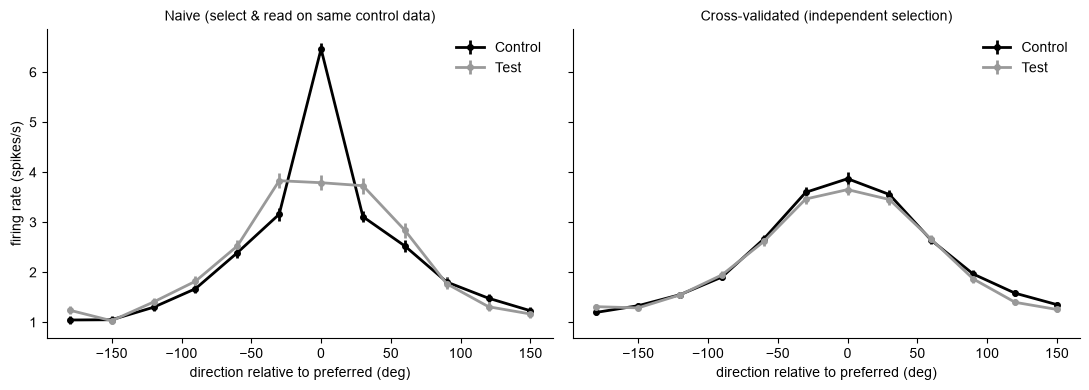

naive gap at pref          : 2.67 sp/s
cross-validated gap at pref : 0.22 sp/s
cross-validated tuning: peak=3.87  flank=2.12 sp/s (still tuned)


In [3]:
# Average the held-out tuning over many random half-splits of the trials
# (ordinary cross-validation). accC/accT accumulate the aligned curves.
n_splits = 60
half = n_trials // 2
accC = np.zeros((n_neurons, n_ori)); accT = np.zeros((n_neurons, n_ori))
for _ in range(n_splits):
    perm = rng.permutation(n_trials)                    # random split of trials
    pick = rate[:, :, CONTROL, perm[:half]].mean(2)     # choose pref here...
    read = rate[:, :, CONTROL, perm[half:]].mean(2)     # ...read control here
    pk = preferred_ori(pick)
    accC += roll_to_center(read, pk)
    accT += roll_to_center(mean_rate[:, :, TEST], pk)   # test never used to pick
cvC = accC / n_splits; cvT = accT / n_splits            # mean held-out tuning curves

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, title, cc, ct in [
        (axes[0], 'Naive (select & read on same control data)', aligned_control, aligned_test),
        (axes[1], 'Cross-validated (independent selection)',     cvC,            cvT)]:
    ax.errorbar(rel_ori, cc.mean(0), cc.std(0)/np.sqrt(n_neurons),
                color='k', lw=2, marker='o', ms=4, label='Control')
    ax.errorbar(rel_ori, ct.mean(0), ct.std(0)/np.sqrt(n_neurons),
                color='0.6', lw=2, marker='o', ms=4, label='Test')
    ax.set_xlabel('direction relative to preferred (deg)'); ax.set_title(title, fontsize=10)
    ax.legend(frameon=False)
axes[0].set_ylabel('firing rate (spikes/s)')
plt.tight_layout(); plt.show()

print(f'naive gap at pref          : {aligned_control[:,center].mean()-aligned_test[:,center].mean():.2f} sp/s')
print(f'cross-validated gap at pref : {cvC[:,center].mean()-cvT[:,center].mean():.2f} sp/s')
print(f'cross-validated tuning: peak={cvC[:,center].mean():.2f}  flank={np.delete(cvC,center,1).mean():.2f} sp/s (still tuned)')


## Bonus artifact: the tuning also looks broader

Look again at the naive panel: the test curve isn't only *lower* at the peak, it
also looks *broader*. Aligning the test data to the **control's** noisy argmax
smears the test response across neighbouring directions, so the same selection
step manufactures an apparent "tuning broadening" on top of the apparent
"responsiveness reduction" -- two spurious effects for the price of one. Both
vanish under cross-validation.


## The "difference" follows whichever condition you select on

If the reduction were real it shouldn't matter which condition defines the
preferred direction. Pick it from the **test** data instead and the inflation
jumps to test: now test > control. The bias lands on whatever you selected with.


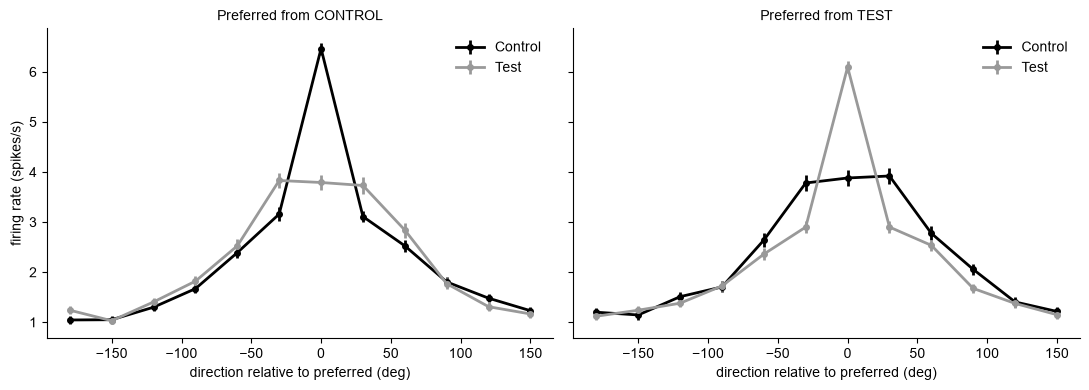

In [4]:
# Same as before, but now choose each neuron's preferred direction from the
# TEST condition, and align both conditions to that instead.
pref_test = preferred_ori(mean_rate[:, :, TEST])
sw_control = roll_to_center(mean_rate[:, :, CONTROL], pref_test)
sw_test    = roll_to_center(mean_rate[:, :, TEST],    pref_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, title, cc, ct in [
        (axes[0], 'Preferred from CONTROL', aligned_control, aligned_test),
        (axes[1], 'Preferred from TEST',    sw_control,      sw_test)]:
    ax.errorbar(rel_ori, cc.mean(0), cc.std(0)/np.sqrt(n_neurons),
                color='k', lw=2, marker='o', ms=4, label='Control')
    ax.errorbar(rel_ori, ct.mean(0), ct.std(0)/np.sqrt(n_neurons),
                color='0.6', lw=2, marker='o', ms=4, label='Test')
    ax.set_xlabel('direction relative to preferred (deg)'); ax.set_title(title, fontsize=10)
    ax.legend(frameon=False)
axes[0].set_ylabel('firing rate (spikes/s)')
plt.tight_layout(); plt.show()


## Why it happens: the winner's curse among near-peak directions

The bias is regression to the mean. Selecting the argmax direction picks a
winner inflated by noise; the more directions sit near the peak (broader tuning),
the more the winner is decided by noise, and the bigger the spurious gap. Sharp
tuning shrinks it but does not remove it.


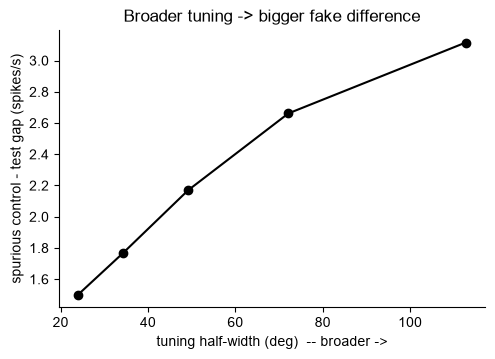

kappa=8: spurious gap = 1.50 sp/s (true difference = 0)
kappa=4: spurious gap = 1.77 sp/s (true difference = 0)
kappa=2: spurious gap = 2.17 sp/s (true difference = 0)
kappa=1: spurious gap = 2.66 sp/s (true difference = 0)
kappa=0.5: spurious gap = 3.12 sp/s (true difference = 0)


In [5]:
# Simulate tuned neurons with a given tuning width (kappa) and NO real
# control/test difference, then measure the fake control-minus-test gap that
# selection produces. Larger kappa = sharper tuning.
def spurious_gap(kappa, reps=200, baseline=1.0, amp=4.0):
    theta = np.deg2rad(np.arange(n_ori) * 30)
    gaps = []
    for _ in range(reps):
        phi = rng.uniform(0, 2*np.pi, n_neurons)            # random preferred dir per neuron
        tun = baseline + amp*np.exp(kappa*(np.cos(theta[None,:]-phi[:,None])-1))  # von Mises tuning
        # two independent Poisson draws from the SAME tuning (control, test):
        C = rng.poisson(tun[:,:,None]*duration, size=(n_neurons,n_ori,n_trials)).mean(2)/duration
        T = rng.poisson(tun[:,:,None]*duration, size=(n_neurons,n_ori,n_trials)).mean(2)/duration
        pk = preferred_ori(C); rows = np.arange(n_neurons)  # pick pref from control
        gaps.append(C[rows,pk].mean() - T[rows,pk].mean())  # gap at that direction
    return np.mean(gaps)

kappas = [8, 4, 2, 1, 0.5]
widths = [np.rad2deg(np.arccos(1 + np.log(0.5)/k)) for k in kappas]  # approx HWHM
gaps = [spurious_gap(k) for k in kappas]

fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(widths, gaps, 'o-', color='k')
ax.set_xlabel('tuning half-width (deg)  -- broader ->')
ax.set_ylabel('spurious control - test gap (spikes/s)')
ax.set_title('Broader tuning -> bigger fake difference')
plt.show()
for k, g in zip(kappas, gaps):
    print(f'kappa={k}: spurious gap = {g:.2f} sp/s (true difference = 0)')


# Act 2 — No tuning at all, fake everything

Now the extreme case. `untuned.npz` has **no orientation tuning**: every spike
count in every condition is drawn from the *same* Poisson rate. The same pipeline
still produces a sharp tuning curve and a large condition difference -- both
entirely manufactured.


In [6]:
# Exactly the same pipeline as the student notebook, now on the untuned data.
counts, duration, orientations, condition_names = load('data/untuned.npz')
n_neurons, n_ori, n_cond, n_trials = counts.shape
rate = counts / duration
mean_rate = rate.mean(axis=3)                        # trial-averaged rate
center = n_ori // 2
rel_ori = (np.arange(n_ori) - center) * (orientations[1] - orientations[0])

pref_idx = preferred_ori(mean_rate[:, :, CONTROL])  # pref direction from control
aligned_control = roll_to_center(mean_rate[:, :, CONTROL], pref_idx)
aligned_test    = roll_to_center(mean_rate[:, :, TEST],    pref_idx)
print(f'naive: control@pref={aligned_control[:,center].mean():.2f}  '
      f'test@pref={aligned_test[:,center].mean():.2f}  '
      f'p={wilcoxon(aligned_control[:,center], aligned_test[:,center]).pvalue:.1e}')


naive: control@pref=2.83  test@pref=0.97  p=4.9e-30


## A second dataset -- and it looks familiar

`untuned.npz` is a completely separate population, with no tuning at all. Run the
identical pipeline and you get the same picture: a sharp peak and a large
control-vs-test gap. Placed next to a real tuning curve from the published
literature, the manufactured result is hard to tell apart from the real thing.


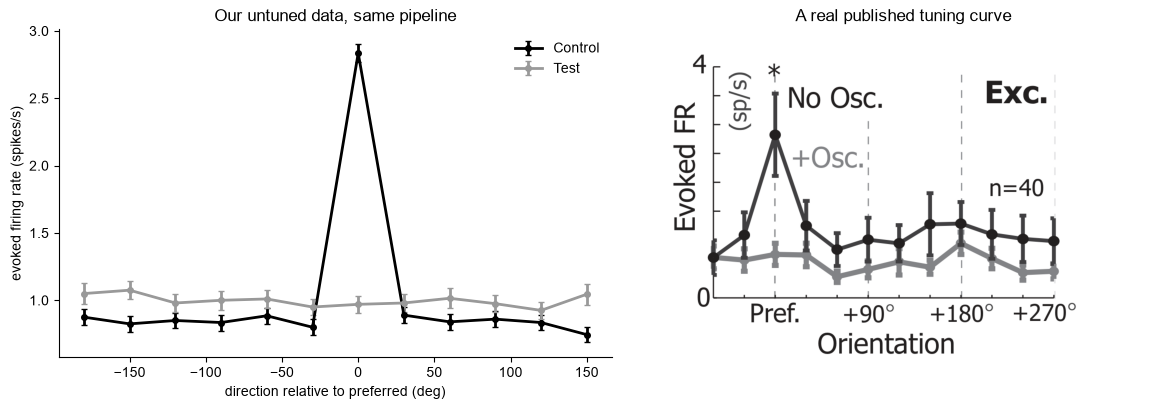

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
for cond, curves in [('control', aligned_control), ('test', aligned_test)]:
    m = curves.mean(0); sem = curves.std(0)/np.sqrt(n_neurons)
    ax.errorbar(rel_ori, m, yerr=sem, color=COND_COLOR[cond], lw=2,
                marker='o', ms=4, capsize=2, label=COND_LABEL[cond])
ax.set_xlabel('direction relative to preferred (deg)')
ax.set_ylabel('evoked firing rate (spikes/s)')
ax.set_title('Our untuned data, same pipeline'); ax.legend(frameon=False)

ax = axes[1]
ax.imshow(plt.imread('published_panel.png'))
ax.axis('off'); ax.set_title('A real published tuning curve')
plt.tight_layout(); plt.show()


## The raw data are untuned and the conditions are identical

Individual "tuning curves" are noise with peaks in random places; the
distribution of "preferred" directions is uniform (no direction is special --
note we break argmax ties at random, else discrete counts bias it toward 0 deg);
and the mean rate per direction is flat and equal across conditions.


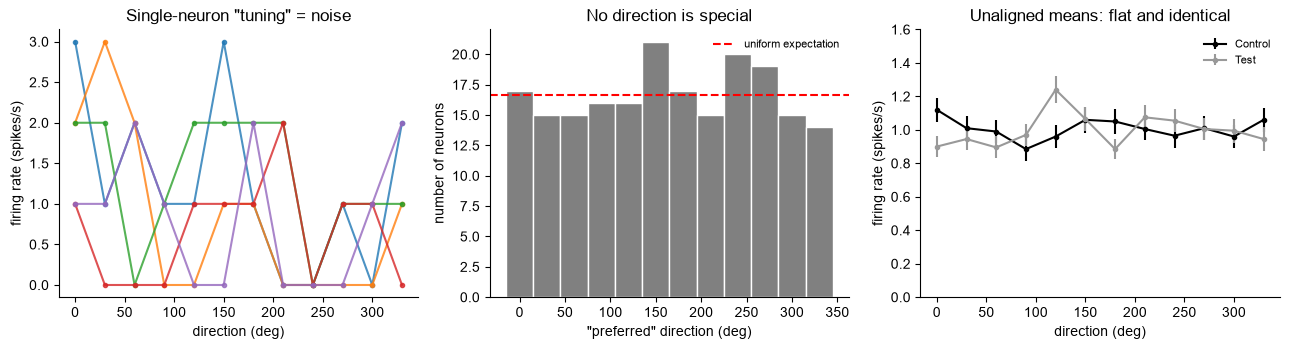

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

ax = axes[0]
for i in range(5):
    ax.plot(orientations, mean_rate[i, :, CONTROL], marker='o', ms=3, alpha=0.8)
ax.set_xlabel('direction (deg)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title('Single-neuron "tuning" = noise')

ax = axes[1]
ax.hist(orientations[pref_idx], bins=np.arange(-15, 360, 30), color='0.5', edgecolor='w')
ax.axhline(n_neurons / n_ori, color='red', ls='--', label='uniform expectation')
ax.set_xlabel('"preferred" direction (deg)'); ax.set_ylabel('number of neurons')
ax.set_title('No direction is special'); ax.legend(frameon=False, fontsize=8)

ax = axes[2]
for c in [CONTROL, TEST]:
    name = condition_names[c]
    m = mean_rate[:, :, c].mean(0); sem = mean_rate[:, :, c].std(0)/np.sqrt(n_neurons)
    ax.errorbar(orientations, m, yerr=sem, color=COND_COLOR[name], marker='o', ms=3,
                label=COND_LABEL[name])
ax.set_xlabel('direction (deg)'); ax.set_ylabel('firing rate (spikes/s)')
ax.set_title('Unaligned means: flat and identical'); ax.set_ylim(0, 1.6)
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


## Cross-validation removes the *entire* peak (not just the gap)

This is the difference from Act 1. There the tuning was real, so cross-validation
kept the peak and only killed the condition difference. Here there is no tuning,
so independent selection flattens **everything**.


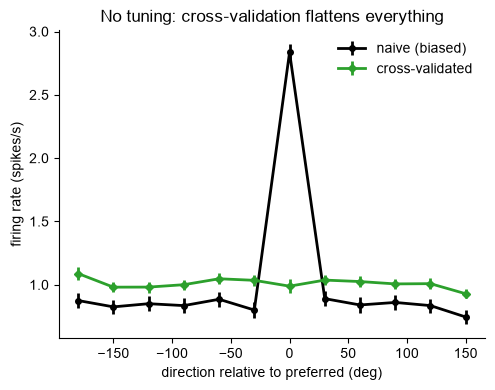

naive peak=2.83  cross-validated peak=0.99 sp/s


In [9]:
# Same cross-validation as Act 1: pick pref on one half of trials, read the
# other half, average over many random splits.
n_splits = 60; half = n_trials // 2
accC = np.zeros((n_neurons, n_ori))
for _ in range(n_splits):
    perm = rng.permutation(n_trials)
    pick = rate[:, :, CONTROL, perm[:half]].mean(2)     # choose pref here
    read = rate[:, :, CONTROL, perm[half:]].mean(2)     # read out here (independent)
    accC += roll_to_center(read, preferred_ori(pick))
cvC = accC / n_splits

fig, ax = plt.subplots(figsize=(5.5, 4))
ax.errorbar(rel_ori, aligned_control.mean(0), aligned_control.std(0)/np.sqrt(n_neurons),
            color='k', lw=2, marker='o', ms=4, label='naive (biased)')
ax.errorbar(rel_ori, cvC.mean(0), cvC.std(0)/np.sqrt(n_neurons),
            color='tab:green', lw=2, marker='D', ms=4, label='cross-validated')
ax.set_xlabel('direction relative to preferred (deg)')
ax.set_ylabel('firing rate (spikes/s)')
ax.set_title('No tuning: cross-validation flattens everything')
ax.legend(frameon=False)
plt.show()
print(f'naive peak={aligned_control[:,center].mean():.2f}  '
      f'cross-validated peak={cvC[:,center].mean():.2f} sp/s')


## Aside — what sets the size of the peak

The winner's curse depends only on the **total spikes collected per direction**
= rate x total counting time (trials x window). It does *not* matter how that
time is sliced: 10 trials of 0.1 s and 1 trial of 1 s give the identical result
(the sum of 10 Poisson(0.1) counts is exactly Poisson(1)). Fewer total spikes ->
bigger manufactured peak.


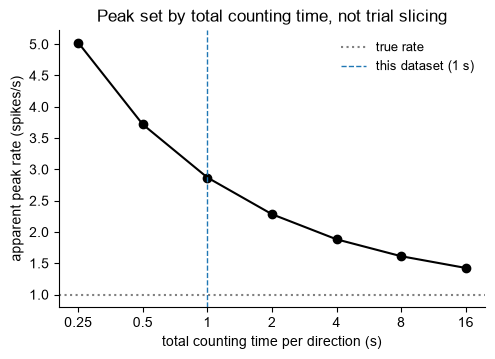

1 trial  x 1.0 s : peak 2.87 sp/s
10 trials x 0.1 s: peak 2.86 sp/s


In [10]:
lam = 1.0
# Simulate untuned neurons observed for a given total counting time (split into
# n_tr trials) and return the apparent peak rate after selecting the argmax
# direction. This isolates how the artifact scales with total spikes collected.
def apparent_peak(total_time, n_tr=1, reps=300):
    window = total_time / n_tr                          # per-trial counting window
    peaks = []
    for _ in range(reps):
        r = rng.poisson(lam*window, size=(n_neurons, n_ori, n_tr)).mean(2)/window
        peaks.append(r[np.arange(n_neurons), preferred_ori(r)].mean())
    return np.mean(peaks)

Ts = [0.25, 0.5, 1, 2, 4, 8, 16]
peaks = [apparent_peak(T) for T in Ts]
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(Ts, peaks, 'o-', color='k'); ax.axhline(lam, color='0.5', ls=':', label='true rate')
ax.axvline(1.0, color='tab:blue', ls='--', lw=1, label='this dataset (1 s)')
ax.set_xscale('log', base=2); ax.set_xticks(Ts); ax.set_xticklabels(Ts)
ax.set_xlabel('total counting time per direction (s)')
ax.set_ylabel('apparent peak rate (spikes/s)')
ax.set_title('Peak set by total counting time, not trial slicing')
ax.legend(frameon=False, fontsize=9); plt.show()

print(f'1 trial  x 1.0 s : peak {apparent_peak(1.0, n_tr=1):.2f} sp/s')
print(f'10 trials x 0.1 s: peak {apparent_peak(1.0, n_tr=10):.2f} sp/s')


## Ground truth


In [11]:
gt = np.load('data/ground_truth.npz', allow_pickle=True)
print('note:', str(gt['note']))
print(f"tuned:   kappa={float(gt['kappa'])}, baseline={float(gt['baseline'])} sp/s, "
      f"amp={float(gt['amp'])} sp/s  (real tuning, identical in both conditions)")
print(f"untuned: flat rate={float(gt['rate'])} sp/s  (no tuning, identical in both conditions)")


note:

 control and test share identical rates in BOTH datasets: no condition difference. tuned.npz has real von Mises tuning; untuned.npz is flat (no tuning).
tuned:   kappa=2.0, baseline=1.0 sp/s, amp=4.0 sp/s  (real tuning, identical in both conditions)
untuned: flat rate=1.0 sp/s  (no tuning, identical in both conditions)


## The lesson

- **Never select and measure on the same data (circular analysis / double
  dipping).** Choosing the preferred direction by argmax and then reporting the
  response *at that direction* biases the value upward. Any statistic used to
  select must be computed on data independent of the statistic you report
  (Kriegeskorte et al., 2009, *Nat. Neurosci.*; Vul et al., 2009).
- **Selection bias can inflate a comparison _or_ manufacture the whole effect.**
  With real tuning it invents a condition difference (Act 1); with no tuning it
  invents the tuning curve itself (Act 2). A single figure often can't tell you
  which of your structure is real -- cross-validation can.
- **The winner's curse is regression to the mean**, biggest when estimates are
  noisy (few spikes) and when many directions sit near the peak (broad tuning).
- **Magnitude is set by total spikes per direction** (rate x trials x window),
  not by how the counting time is sliced.

**How to do it right:** define the preferred direction on one set of trials and
quantify tuning / condition differences on independent trials
(cross-validation); or avoid peak-alignment and compare conditions with an
alignment-free model (a fitted tuning function, or the full direction x condition
response in a proper repeated-measures model). Do that here and the condition
difference is zero -- as it must be, since control and test were generated
identically.
